(morris_learn)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 贝叶斯学习下的投机行为

```{index} single: Models; Morris Learning
```

```{contents} Contents
:depth: 2
```

## 概述

本讲介绍 {cite:t}`Morris1996` 如何扩展了 Harrison–Kreps 的投机资产定价模型 {cite}`HarrKreps1978`。

与 Harrison 和 Kreps 的模型一样，Morris 的模型确定了一种支付股息的资产的价格，该资产由具有异质信念的风险中性投资者进行交易。

Harrison-Kreps 模型假设交易者对资产的股息流具有教条式的、固定的信念。

Morris 用运用贝叶斯定律来更新其对未来股息信念的交易者，替换了 Harrison 和 Kreps 那些对股息流持有固定信念的交易者——随着新的股息数据到来，这些交易者会更新信念。

```{note}
Morris 的交易者不使用资产过去价格的数据来更新他们对股息过程的信念。
```

Morris 模型环境的关键特征包括：

* 所有交易者共享一套关于未来股息的统计模型
* 单一参数为这套统计模型索引
* 所有交易者观察到相同的股息历史
* 所有交易者使用贝叶斯定律来更新信念
* 交易者对该参数有不同的初始*先验分布*
* 交易者对该参数的*后验分布*最终会趋于一致
* 在后验分布趋于一致之前，交易者对未来股息的预测密度存在分歧
    * 因此他们对资产价值存在分歧

正如在 Harrison 和 Kreps 的固定信念模型中一样，这些意见分歧会促使投资者从事以下意义上的*投机行为*：

 * 有时他们愿意为资产支付比他们认为的"基本"价值更高的价格，即其未来股息流的预期贴现值

在阅读本讲之前，你可能想复习以下 quantecon 讲座：

* {doc}`Harrison-Kreps 模型 <harrison_kreps>`
* {doc}`似然比过程 <likelihood_ratio_process>`
* {doc}`贝叶斯统计与频率派统计 <likelihood_bayes>`

让我们从一些标准导入开始：

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"
mpl.font_manager.fontManager.addfont(FONTPATH)
plt.rcParams['font.family'] = ['Source Han Serif SC']

## 模型结构

某种资产的股份供给量是固定的。

每一股赋予其所有者一个*二元* i.i.d. 股息流 $\{d_t\}$，其中

$$
d_{t+1} \in \{0,1\}
$$

时刻 $t$ 的股息以未知概率 $\theta \in (0,1)$ 等于 $1$，以概率 $1-\theta$ 等于 $0$。

与 {cite}`HarrKreps1978` 中交易者对马尔可夫转移矩阵持有固定信念不同，在 Morris 的模型中：

* 真实的股息概率 $\theta$ 是未知的
* 交易者对 $\theta$ 有*先验信念*
* 交易者观察股息实现值，并通过贝叶斯定律更新信念

存在一个有限的*风险中性*交易者集合 $\mathcal{I}$。

所有交易者具有相同的贴现因子 $\beta \in (0,1)$。

* 你可以把 $\beta$ 看作通过 $\beta = 1/(1+r)$ 与净无风险利率 $r$ 相关联。

在第 $t$ 期末持有资产的所有者有权获得时刻 $t+1, t+2, \ldots$ 的股息。

由于股息过程是 i.i.d. 的，交易者 $i$ 认为资产的基本价值是股息流的资本化价值，即 $\sum_{j=1}^\infty \beta^j \hat \theta_i 
= \frac{\hat \theta_i}{r}$，其中 $\hat \theta_i$ 是该交易者关于 $\theta$ 的后验分布的均值。

### 可能的交易

交易者在每个时期 $t = 0, 1, 2, \ldots$ 于股息支付后，在竞争市场上买卖这种风险资产。

与 Harrison-Kreps 中一样：

* 该资产以*除息*方式交易
* 在时刻 $t$ 末持有一股的所有者有权获得时刻 $t+1$ 的股息
* 在第 $t$ 期末持有一股的所有者还有权在收到时刻 $t+1$ 的股息后，于时刻 $t+1$ 出售该股份。

*禁止卖空*。

这一点很重要，因为它限制了悲观者表达其观点的方式：

* 他们*可以*通过出售自己的股份来表达观点
* 他们*不能*通过借入股份并立即出售的方式来更强烈地表达观点

所有交易者都有足够的财富来购买风险资产。

## 信息与信念

在时刻 $t \geq 1$，所有交易者观察到 $(d_1, d_2, \ldots, d_t)$。

所有交易者通过应用贝叶斯规则来更新他们关于 $\theta$ 的主观分布。

交易者对未知的股息概率 $\theta$ 具有*异质先验*。

先验中的这种异质性产生了异质的后验信念。

## 异质先验的来源

将不同的统计模型赋予模型内部的主体是有争议的。

许多博弈论学者和理性预期的应用经济学家认为这是个坏主意。

虽然这些经济学家经常构建其中主体拥有不同*信息*的模型，但他们更倾向于假设模型内部所有主体始终共享相同的统计模型——即对被建模的随机过程具有相同的联合概率分布。

对于统计学家或经济理论家而言，统计模型是由已知参数向量所刻画的联合概率分布。

当处理由参数（例如已知集合 $\Theta$ 中的 $\theta$）扫出的一*组*统计模型时，经济理论家通过将同一个关于 $\theta$ 的先验概率分布赋予模型内部所有主体，将这组模型简化为单一模型。


```{note}
一组具有特定几何结构的统计模型称为统计模型的[流形](https://en.wikipedia.org/wiki/Manifold)。Morris 赋予交易者一个共享的统计模型流形。
```

以这种方式进行遵循了*哈萨尼共同先验学说*。



{cite}`harsanyi1967games`、{cite}`harsanyi1968games`、{cite}`harsanyi1968games3` 论证说，如果两个理性主体具有相同的信息和相同的推理能力，他们对相关结果将具有相同的联合概率分布。

哈萨尼将关于未来结果的分歧解释为源于主体信息集的差异，而非其统计模型的差异。


显然，{cite}`HarrKreps1978` 在固定教条式的不同信念时，背离了哈萨尼的共同统计模型假设。

{cite:t}`Morris1996` 对哈萨尼学说的背离不如 Harrison 和 Kreps 那么彻底。

  * Morris 确实假设主体共享相同的统计模型集合，但 $\ldots$
  * Morris 假设他们对索引这些模型的参数具有不同的初始先验分布

Morris 的主体以不同的方式表达他们对参数的初始无知——他们具有不同的先验。


Morris 通过援引 {cite}`miller1977risk` 提出的首次公开募股的明显"错误定价"来为他的假设辩护。

Miller 描述了这样一种情况：主体几乎没有或完全没有关于一个新企业的数据。

Morris 希望他的交易者在关于参数的信息到来时能够改变他们的观点。

众所周知，知识渊博的统计学家对于适当的先验会有分歧。

例如，Morris 描述了*不同*的、值得尊重的方式来表达对伯努利分布参数的"最大无知"

 * $[0, 1]$ 上的均匀分布
 * 对重参数化不变的杰弗里斯先验 {cite}`jeffreys1946invariant`；在当前情形下，杰弗里斯先验采取参数为 $.5, .5$ 的贝塔分布的形式

这些先验中的一个是否比另一个更"理性"？

Morris 认为不是。




## 贝塔先验

为了便于处理，假设交易者 $i$ 对股息概率具有贝塔先验

$$
\theta \sim \text{Beta}(a_i, b_i)
$$

其中 $a_i, b_i > 0$ 是先验参数。

```{note}
贝塔分布也出现在以下 quantecon 讲座中 {doc}`divergence_measures`、{doc}`likelihood_ratio_process`、{doc}`odu`。
```

假设交易者 $i$ 观察到一段 $t$ 期的历史，其中共支付了 $s$ 次股息（即 $s$ 次有股息的成功和 $t-s$ 次无股息的失败）。

根据贝叶斯规则，关于 $\theta$ 的后验密度为：

$$
\pi_i(\theta \mid s, t) = \frac{\theta^s (1-\theta)^{t-s} \pi_i(\theta)}{\int_0^1 \theta^s (1-\theta)^{t-s} \pi_i(\theta) d\theta}
$$

其中 $\pi_i(\theta)$ 是交易者 $i$ 的先验密度。

```{note}
贝塔分布是二项似然的共轭先验。这意味着当先验为 $\text{Beta}(a_i, b_i)$ 且我们在 $t$ 次试验中观察到 $s$ 次成功时，后验为 $\text{Beta}(a_i+s, b_i+t-s)$。
```

后验均值（或预期股息概率）为：

$$
\mu_i(s,t) = \int_0^1 \theta \pi_i(\theta \mid s, t) d\theta 
= \mathbb{E}[\text{Beta}(a_i+s, b_i+t-s)] = \frac{a_i + s}{a_i + b_i + t}
$$

Morris 将 $\mu_i(s,t)$ 称为交易者 $i$ 在历史 $(s,t)$ 之后对资产的**基本估值**。

这是交易者 $i$ 赋予下一期收到股息的概率。

它嵌入了交易者 $i$ 关于 $\theta$ 的更新信念。

## 具有学习的市场价格

基本估值等于我们的异质交易者赋予*永久*持有资产这一选择的股息预期现值。

均衡价格过程由以下条件确定：在时刻 $t$ 资产由在时刻 $t$ 对资产赋予最高估值的交易者持有。

资产的所有者可以选择在收到当期股息后出售它。

交易者会将此考虑在内。

这就产生了一种可能性：交易者愿意为资产支付比该交易者的基本估值更高的价格。

```{prf:definition} 最乐观估值
:label: most_optimistic_valuation

在历史 $(s,t)$ 之后，*最乐观的基本估值*为：

$$
\mu^*(s,t) = \max_{i \in \mathcal{I}} \mu_i(s,t)
$$
```

```{prf:definition} 均衡资产价格
:label: equilibrium_asset_price

将 $\tilde{p}(s,t,r)$ 记为当利率为 $r$ 时，在历史 $(s,t)$ 之后风险资产的竞争均衡价格（以当前美元计）。

均衡价格满足：

$$
\tilde{p}(s,t,r) = \frac{1}{1+r} \Bigl[ \mu^*(s,t) \{1 + \tilde{p}(s+1,t+1,r)\} 
+ (1 - \mu^*(s,t)) \tilde{p}(s,t+1,r) \Bigr]
$$
```

均衡价格等于所有交易者中持有资产至下一期所获得的最高预期贴现回报。

```{prf:definition} 归一化价格
:label: normalized_price

将归一化价格定义为：

$$
p(s,t,r) = r \tilde{p}(s,t,r)
$$

由于无风险资产当前的"美元"价格为 $1/r$，这表示以无风险资产为单位的风险资产价格。
```

将前面的公式代入均衡条件得到：

$$
p(s,t,r) = \frac{r}{1+r} \mu^*(s,t) + \frac{1}{1+r} 
\Bigl[ \mu^*(s,t) p(s+1,t+1,r) + (1 - \mu^*(s,t)) p(s,t+1,r) \Bigr]
$$

或等价地：

$$
p(s,t,r) = \mu^*(s,t) + \frac{r}{1+r} 
\Bigl[ \mu^*(s,t) p(s+1,t+1,r) + (1 - \mu^*(s,t)) p(s,t+1,r) - \mu^*(s,t) \Bigr]
$$

满足均衡条件的价格函数可以递归计算。

设 $p^0(s,t,r) = 0$ 对所有 $(s,t,r)$ 成立，并通过下式定义 $p^{n+1}(s,t,r)$：

$$
p^{n+1}(s,t,r) = \frac{r}{1+r} \mu^*(s,t) + \frac{1}{1+r} 
\Bigl[ \mu^*(s,t) p^n(s+1,t+1,r) + (1 - \mu^*(s,t)) p^n(s,t+1,r) \Bigr]
$$

序列 $\{p^n(s,t,r)\}$ 收敛到均衡价格 $p(s,t,r)$。

```{prf:definition} 投机溢价
:label: speculative_premium

当最乐观交易者的身份会随未来股息实现值而切换时，市场价格超过*每一位*交易者的基本估值。

以归一化单位表示：

$$
p(s,t,r) > \mu_i(s,t) \quad \text{对所有 } i \in \mathcal{I}
$$

将**投机溢价**定义为：

$$
p(s,t,r) - \mu^*(s,t) > 0
$$
```


## 两个交易者

我们现在聚焦于一个具有两个交易者的例子，他们的贝塔先验参数分别为 $(a_1,b_1)$ 和 $(a_2,b_2)$。

```{prf:definition} 比率支配（贝塔先验）
:label: rate_dominance_beta

如果满足以下条件，则交易者 1 **比率支配**交易者 2：

$$
a_1 \geq a_2 \quad \text{和} \quad b_1 \leq b_2
$$
```

```{prf:theorem} 全局乐观者（两个交易者）
:label: two_trader_optimist

对于具有贝塔先验的两个交易者：

1. 如果交易者 1 比率支配交易者 2，则交易者 1 是**全局乐观者**：对所有历史 $(s,t)$，有 $\mu_1(s,t) \geq \mu_2(s,t)$
2. 在这种 $p(s,t,r) = \mu_1(s,t)$ 对所有 $(s,t,r)$ 成立的情形下，*不存在投机溢价*。
```

当两个交易者中没有一个比率支配另一个时，最乐观交易者的身份可能随着股息累积而切换。

在发生永久切换的历史路径上，只要交易者继续存在分歧，资产价格就会严格超过两个交易者的基本估值：

$$
p(s,t,r) > \max\{\mu_1(s,t), \mu_2(s,t)\}
$$

因此，在这样的历史路径上，存在持续的投机溢价。

### 实现

为了便于计算，我们使用有限视界 $T$ 并通过后向归纳求解。

```{note}
在第 1122 页，{cite:t}`Morris1996` 提供了一个论证：这类有限视界经济当 $T\rightarrow + \infty$ 时的极限提供了一个有用的选择算法，它排除了涉及庞氏骗局价格成分的额外均衡，Morris 认为这些均衡是脆弱的，予以摒弃。
```

遵循 {prf:ref}`equilibrium_asset_price`，我们使用贴现因子参数化 $\beta = 1/(1+r)$ 并通过下式计算美元价格 $\tilde{p}(s,t)$：

$$
\tilde{p}(s,t) = \beta \max_{i\in\{1,2\}} \Bigl[ \mu_i(s,t) \{1 + \tilde{p}(s+1,t+1)\} + (1-\mu_i(s,t)) \tilde{p}(s,t+1) \Bigr]
$$

我们将终端价格 $\tilde{p}(s,T)$ 设为最乐观信念下的永续年金价值。

In [2]:
def posterior_mean(a, b, s, t):
    """
    计算 Beta(a, b) 先验的后验均值 μ_i(s,t)。
    """
    return (a + s) / (a + b + t)

def perpetuity_value(a, b, s, t, β=.75):
    """
    计算永续年金价值 (β/(1-β)) * μ_i(s,t)。
    """
    return (β / (1 - β)) * posterior_mean(a, b, s, t)

def price_learning_two_agents(prior1, prior2, β=.75, T=200):
    """
    通过后向归纳计算两个贝塔先验交易者的 \tilde p(s,t)。
    """
    a1, b1 = prior1
    a2, b2 = prior2
    price_array = np.zeros((T+1, T+1))

    # 终端条件：设为最大信念下的永续年金价值
    for s in range(T+1):
        perp1 = perpetuity_value(a1, b1, s, T, β)
        perp2 = perpetuity_value(a2, b2, s, T, β)
        price_array[s, T] = max(perp1, perp2)

    # 后向归纳
    for t in range(T-1, -1, -1):
        for s in range(t, -1, -1):
            μ1 = posterior_mean(a1, b1, s, t)
            μ2 = posterior_mean(a2, b2, s, t)
            
            # 每个交易者信念下的单步延续值
            cont1 = μ1 * (1.0 + price_array[s+1, t+1]) \
                    + (1.0 - μ1) * price_array[s, t+1]
            cont2 = μ2 * (1.0 + price_array[s+1, t+1]) \
                    + (1.0 - μ2) * price_array[s, t+1]
            price_array[s, t] = β * max(cont1, cont2)

    def μ1_fun(s, t):
        return posterior_mean(a1, b1, s, t)
    def μ2_fun(s, t):
        return posterior_mean(a2, b2, s, t)

    return price_array, μ1_fun, μ2_fun

(hk_go)=
### 情形 A：全局乐观者（无溢价）

选择具有比率支配的先验，例如，交易者 1：$\text{Beta}(a_1,b_1)=(2,1)$ 和交易者 2：$(a_2,b_2)=(1,2)$。

交易者 1 是全局乐观者，因此归一化价格等于交易者 1 的基本估值：$p(s,t,r) = \mu_1(s,t)$。

In [3]:
β = 0.75
price_go, μ1_go, μ2_go = price_learning_two_agents(
        (2,1), (1,2), β=β, T=200)

perpetuity_1 = (β / (1 - β)) * μ1_go(0, 0)
perpetuity_2 = (β / (1 - β)) * μ2_go(0, 0)

print("Price at (0, 0) =", price_go[0,0])
print("Valuation of trader 1 at (0, 0) =", perpetuity_1)
print("Valuation of trader 2 at (0, 0) =", perpetuity_2)

Price at (0, 0) = 2.0
Valuation of trader 1 at (0, 0) = 2.0
Valuation of trader 2 at (0, 0) = 1.0


价格等于交易者 1 的永续年金价值。

### 情形 B：永久切换（正溢价）

现在假设交易者 1 具有 $\text{Beta}(1,1)$，交易者 2 具有 $\text{Beta}(1/2,1/2)$。

这些会产生交叉的后验，因此不存在全局乐观者，且价格在早期超过两者的基本价值。

In [4]:
price_ps, μ1_ps, μ2_ps = price_learning_two_agents(
                                (1,1), (0.5,0.5), β=β, T=200)

price_00 = price_ps[0,0]
μ1_00 = μ1_ps(0,0)
μ2_00 = μ2_ps(0,0)

perpetuity_1 = (β / (1 - β)) * μ1_ps(0, 0)
perpetuity_2 = (β / (1 - β)) * μ2_ps(0, 0)

print("Price at (0, 0) =", np.round(price_00, 6))
print("Valuation of trader 1 at (0, 0) =", perpetuity_1)
print("Valuation of trader 2 at (0, 0) =", perpetuity_2)

Price at (0, 0) = 1.599322
Valuation of trader 1 at (0, 0) = 1.5
Valuation of trader 2 at (0, 0) = 1.5


由此产生的溢价反映了这样一种期权价值：当股息依次到来时，可以将资产转售给暂时变得更乐观的任一交易者。

在这一设定中，我们可以重现 {cite:t}`Morris1996` 报告的两个关键图形

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


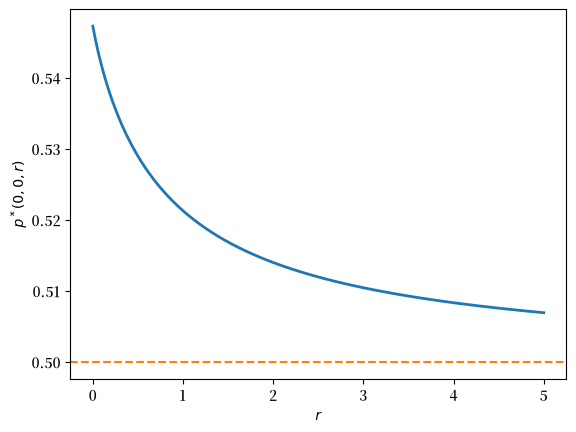

In [5]:
def normalized_price_two_agents(prior1, prior2, r, T=250):
    """返回两个交易者的 p(s,t,r) = r \tilde p(s,t,r)。"""
    β = 1.0 / (1.0 + r)
    price_array, *_ = price_learning_two_agents(prior1, prior2, β=β, T=T)
    return r * price_array

# 图 I：p*(0,0,r) 作为 r 的函数
r_grid = np.linspace(1e-3, 5.0, 200)
priors = ((1,1), (0.5,0.5))
p00 = np.array([normalized_price_two_agents(
                priors[0], priors[1], r, T=300)[0,0]
                for r in r_grid])

fig, ax = plt.subplots()
ax.plot(r_grid, p00, lw=2)
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$p^*(0,0,r)$')
ax.axhline(0.5, color='C1', linestyle='--')
plt.show()

在第一幅图中，注意：

- 转售期权将归一化价格 $p^*(0,0,r)$ 推高到基本价值 $(0.5)$ 之上，对任何有限的 $r$ 都成立。

- 随着 $r$ 增加（$\beta$ 减小），期权价值消退，$p^*(0,0,r) \to 0.5$。

- 在 $r = 0.05$ 处，溢价约为 $8–9\%$，与 Morris (1996, 第 IV 节) 一致。

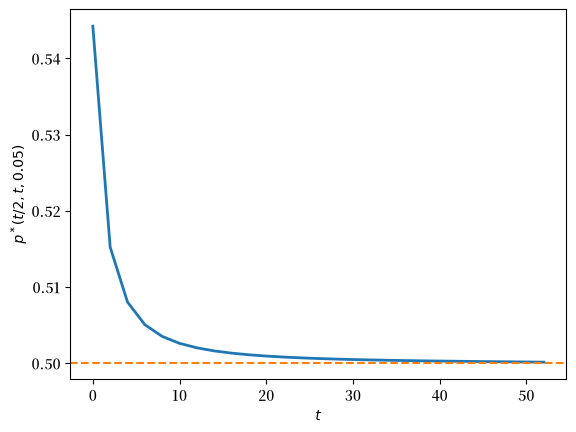

Initial normalized premium at r=0.05 (%): 8.85


In [6]:
# 图 II：p*(t/2,t,0.05) 作为 t 的函数
r = 0.05
T = 60
p_mat = normalized_price_two_agents(priors[0], priors[1], r, T=T)
t_vals = np.arange(0, 54, 2)
s_vals = t_vals // 2
y = np.array([p_mat[s, t] for s, t in zip(s_vals, t_vals)])

fig, ax = plt.subplots()
ax.plot(t_vals, y, lw=2)
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$p^*(t/2,t,0.05)$')
ax.axhline(0.5, color='C1', linestyle='--')
plt.show()

p0 = p_mat[0,0]
μ0 = 0.5
print("Initial normalized premium at r=0.05 (%):",
      np.round(100 * (p0 / μ0 - 1.0), 2))

在第二幅图中，注意：

- 沿对称路径 $s = t/2$，两个交易者的基本估值在每个 $t$ 处都等于 $0.5$，然而价格从高于 $0.5$ 开始，并随着学习减少分歧、转售期权失去价值而向 $0.5$ 下降。


### 一般的 N 交易者扩展

同样的递归可以通过每一期对 $i$ 取最大值，扩展到任何有限的贝塔先验集合 $\{(a_i,b_i)\}_{i=1}^N$。

In [7]:
def price_learning(priors, β=0.75, T=200):
    """
    具有异质贝塔先验的 N 交易者版本。
    """
    price_array = np.zeros((T+1, T+1))

    def perp_i(i, s, t):
        a, b = priors[i]
        return perpetuity_value(a, b, s, t, β)

    # 终端条件
    for s in range(T+1):
        price_array[s, T] = max(
            perp_i(i, s, T) for i in range(len(priors)))

    # 后向归纳
    for t in range(T-1, -1, -1):
        for s in range(t, -1, -1):
            conts = []
            for (a, b) in priors:
                μ = posterior_mean(a, b, s, t)
                conts.append(μ * 
                (1.0 + price_array[s+1, t+1]) 
                     + (1.0 - μ) * price_array[s, t+1])
            price_array[s, t] = β * max(conts)

    return price_array

β = 0.75
priors = [(1,1), (0.5,0.5), (3,2)]
price_N = price_learning(priors, β=β, T=150)

# 计算每个交易者在 (0,0) 处的估值
μ_vals = [posterior_mean(a, b, 0, 0) for a, b in priors]
perp_vals = [(β / (1 - β)) * μ for μ in μ_vals]

print("Three-trader example at (s,t)=(0,0):")
print(f"Price at (0,0) = {np.round(price_N[0,0], 6)}")
print(f"\nTrader valuations:")
for i, (μ, perp) in enumerate(zip(μ_vals, perp_vals), 1):
    print(f"  Trader {i} = {np.round(perp, 6)}")

Three-trader example at (s,t)=(0,0):
Price at (0,0) = 1.937972

Trader valuations:
  Trader 1 = 1.5
  Trader 2 = 1.5
  Trader 3 = 1.8


注意资产价格高于所有交易者的估值。

Morris 告诉我们在这种情况下不存在比率支配。

让我们使用下面的代码来验证这一点

In [8]:
dominant = None
for i in range(len(priors)):
    is_dom = all(
        priors[i][0] >= priors[j][0] and priors[i][1] <= priors[j][1]
                 for j in range(len(priors)) if i != j)
    if is_dom:
        dominant = i
        break

if dominant is not None:
    print(f"\nTrader {dominant+1} is the global optimist (rate-dominant)")
else:
    print(f"\nNo global optimist and speculative premium exists")


No global optimist and speculative premium exists


的确，不存在全局乐观者，且存在投机溢价。

## 结束语

{cite:t}`Morris1996` 使用他的模型来解释 {cite}`miller1977risk` 描述的一种"热门发行"异象，根据该异象，首次公开募股的开盘市场价格似乎高于后来出现的价值价格。



## 练习

```{exercise-start}
:label: hk_ex3
```

Morris {cite}`Morris1996` 对投机泡沫何时出现给出了尖锐的刻画。

关键条件是不存在*全局乐观者*。

在本练习中，你将为以下几组具有贝塔先验的交易者验证这一条件：

1. 交易者 1：$\text{Beta}(2,1)$，交易者 2：$\text{Beta}(1,2)$
2. 交易者 1：$\text{Beta}(1,1)$，交易者 2：$\text{Beta}(1/2,1/2)$
3. 交易者 1：$\text{Beta}(3,1)$，交易者 2：$\text{Beta}(2,1)$，交易者 3：$\text{Beta}(1,2)$
4. 交易者 1：$\text{Beta}(1,1)$，交易者 2：$\text{Beta}(1/2,1/2)$，交易者 3：$\text{Beta}(3/2,3/2)$

```{exercise-end}
```

```{solution-start} hk_ex3
:class: dropdown
```

这是一个解答：

In [9]:
def check_rate_dominance(priors):
    """
    检查是否有某个交易者比率支配所有其他交易者。
    """
    N = len(priors)

    for i in range(N):
        a_i, b_i = priors[i]
        is_dominant = True

        for j in range(N):
            if i == j:
                continue
            a_j, b_j = priors[j]

            # 检查比率支配条件
            if not (a_i >= a_j and b_i <= b_j):
                is_dominant = False
                break

        if is_dominant:
            return i

    return None

# 测试用例
test_cases = [
    ([(2, 1), (1, 2)], "Global optimist exists"),
    ([(1, 1), (0.5, 0.5)], "Perpetual switching"),
    ([(3, 1), (2, 1), (1, 2)], "Three traders with dominant"),
    ([(1, 1), (0.5, 0.5), (1.5, 1.5)], "Three traders, no dominant")
]

for priors, description in test_cases:
    dominant = check_rate_dominance(priors)

    print(f"\n{description}")
    print(f"Priors: {priors}")
    print("=="*8)
    if dominant is not None:
        print(f"Trader {dominant+1} is the global optimist (rate-dominant)")
    else:
        print(f"No global optimist exists")
    print("=="*8 + "\n")


Global optimist exists
Priors: [(2, 1), (1, 2)]
Trader 1 is the global optimist (rate-dominant)


Perpetual switching
Priors: [(1, 1), (0.5, 0.5)]
No global optimist exists


Three traders with dominant
Priors: [(3, 1), (2, 1), (1, 2)]
Trader 1 is the global optimist (rate-dominant)


Three traders, no dominant
Priors: [(1, 1), (0.5, 0.5), (1.5, 1.5)]
No global optimist exists


```{solution-end}
```